In [1]:
import numpy as np
import pandas as pd
import requests
from io import StringIO

In [2]:
#Usar requests
#response = requests.get("https://ecobici.cdmx.gob.mx/wp-content/uploads/2025/02/2025-01.csv")
#df = pd.read_csv(StringIO(response.text))

In [3]:
##leerdirectamente desde URL
#df = pd.read_csv("https://ecobici.cdmx.gob.mx/wp-content/uploads/2025/02/2025-01.csv")
df = pd.read_csv('2025-01.csv')

**Calculo de moda, media y mediana**

In [4]:
df.mode()

,Genero_Usuario,Edad_Usuario,Bici,Ciclo_Estacion_Retiro,Fecha_Retiro,Hora_Retiro,Ciclo_EstacionArribo,Fecha_Arribo,Hora_Arribo
0,M,30.0,8537367,271-272,29/01/2025,18:05:49,271-272,29/01/2025,18:34:56


In [5]:
df.mean(numeric_only=True)

Edad_Usuario    3.400352e+01
Bici            5.456875e+06
dtype: float64

In [6]:
df.median(numeric_only=True)

Edad_Usuario         32.0
Bici            5452651.0
dtype: float64

In [7]:
df.head(10)

,Genero_Usuario,Edad_Usuario,Bici,Ciclo_Estacion_Retiro,Fecha_Retiro,Hora_Retiro,Ciclo_EstacionArribo,Fecha_Arribo,Hora_Arribo
0,M,26.0,5180930,568,31/12/2024,23:57:02,572,01/01/2025,00:00:03
1,F,54.0,3653953,283,31/12/2024,23:51:40,596,01/01/2025,00:00:41
2,M,38.0,7511322,034,31/12/2024,23:48:36,064,01/01/2025,00:00:59
3,M,41.0,3804572,258,31/12/2024,23:54:11,023,01/01/2025,00:01:08
4,M,35.0,3848405,043,31/12/2024,23:35:28,126,01/01/2025,00:01:17
5,M,24.0,7579436,222,31/12/2024,23:34:33,483,01/01/2025,00:01:58
6,M,31.0,7161920,034,31/12/2024,23:25:47,688,01/01/2025,00:02:16
7,M,22.0,7220593,254,31/12/2024,23:50:20,539,01/01/2025,00:02:41
8,M,29.0,4031258,560,31/12/2024,23:52:11,120,01/01/2025,00:03:28
9,F,24.0,6463376,560,31/12/2024,23:51:50,120,01/01/2025,00:03:31


In [8]:
print("El número total de registros es:",len(df))

El número total de registros es: 1809775


In [9]:
print("Tamaño del dataset")
print(df.shape)

Tamaño del dataset
(1809775, 9)


In [10]:
df.isnull().sum()

Genero_Usuario             1
Edad_Usuario             147
Bici                       0
Ciclo_Estacion_Retiro      0
Fecha_Retiro               0
Hora_Retiro                0
Ciclo_EstacionArribo       0
Fecha_Arribo               0
Hora_Arribo                0
dtype: int64

In [11]:
df['Hora_Retiro'] = df['Hora_Retiro'].astype(str)
df['Hora_Arribo'] = df['Hora_Arribo'].astype(str)
df['Fecha_Retiro'] = df['Fecha_Retiro'].astype(str)
df['Fecha_Arribo'] = df['Fecha_Arribo'].astype(str)

In [12]:
df.dtypes

Genero_Usuario            object
Edad_Usuario             float64
Bici                       int64
Ciclo_Estacion_Retiro     object
Fecha_Retiro              object
Hora_Retiro               object
Ciclo_EstacionArribo      object
Fecha_Arribo              object
Hora_Arribo               object
dtype: object

In [13]:
df['Fecha_Hora_Retiro'] =  df['Fecha_Retiro'] + ' ' + df['Hora_Retiro']
df['Fecha_Hora_Arribo'] =  df['Fecha_Arribo'] + ' ' + df['Hora_Arribo']

In [14]:
df.head()

,Genero_Usuario,Edad_Usuario,Bici,Ciclo_Estacion_Retiro,Fecha_Retiro,Hora_Retiro,Ciclo_EstacionArribo,Fecha_Arribo,Hora_Arribo,Fecha_Hora_Retiro,Fecha_Hora_Arribo
0,M,26.0,5180930,568,31/12/2024,23:57:02,572,01/01/2025,00:00:03,31/12/2024 23:57:02,01/01/2025 00:00:03
1,F,54.0,3653953,283,31/12/2024,23:51:40,596,01/01/2025,00:00:41,31/12/2024 23:51:40,01/01/2025 00:00:41
2,M,38.0,7511322,034,31/12/2024,23:48:36,064,01/01/2025,00:00:59,31/12/2024 23:48:36,01/01/2025 00:00:59
3,M,41.0,3804572,258,31/12/2024,23:54:11,023,01/01/2025,00:01:08,31/12/2024 23:54:11,01/01/2025 00:01:08
4,M,35.0,3848405,043,31/12/2024,23:35:28,126,01/01/2025,00:01:17,31/12/2024 23:35:28,01/01/2025 00:01:17


In [15]:
df['Fecha_Hora_Retiro'] = pd.to_datetime(df['Fecha_Hora_Retiro'],dayfirst=True)
df['Fecha_Hora_Arribo'] = pd.to_datetime(df['Fecha_Hora_Arribo'],dayfirst=True)

In [16]:
df.dtypes

Genero_Usuario                   object
Edad_Usuario                    float64
Bici                              int64
Ciclo_Estacion_Retiro            object
Fecha_Retiro                     object
Hora_Retiro                      object
Ciclo_EstacionArribo             object
Fecha_Arribo                     object
Hora_Arribo                      object
Fecha_Hora_Retiro        datetime64[ns]
Fecha_Hora_Arribo        datetime64[ns]
dtype: object

In [17]:
df['duracion'] = df['Fecha_Hora_Arribo'] - df['Fecha_Hora_Retiro']

In [18]:
#es mas recomendable usar la mediana y no la media
df['Edad_Usuario'] = df['Edad_Usuario'].transform(lambda x: x.fillna(x.median())) 

In [19]:
#df = pd.get_dummies(df, columns=['Genero_Usuario'], prefix=['Genero_Usuario'])

In [20]:
df.head()

,Genero_Usuario,Edad_Usuario,Bici,Ciclo_Estacion_Retiro,Fecha_Retiro,Hora_Retiro,Ciclo_EstacionArribo,Fecha_Arribo,Hora_Arribo,Fecha_Hora_Retiro,Fecha_Hora_Arribo,duracion
0,M,26.0,5180930,568,31/12/2024,23:57:02,572,01/01/2025,00:00:03,2024-12-31 23:57:02,2025-01-01 00:00:03,0 days 00:03:01
1,F,54.0,3653953,283,31/12/2024,23:51:40,596,01/01/2025,00:00:41,2024-12-31 23:51:40,2025-01-01 00:00:41,0 days 00:09:01
2,M,38.0,7511322,034,31/12/2024,23:48:36,064,01/01/2025,00:00:59,2024-12-31 23:48:36,2025-01-01 00:00:59,0 days 00:12:23
3,M,41.0,3804572,258,31/12/2024,23:54:11,023,01/01/2025,00:01:08,2024-12-31 23:54:11,2025-01-01 00:01:08,0 days 00:06:57
4,M,35.0,3848405,043,31/12/2024,23:35:28,126,01/01/2025,00:01:17,2024-12-31 23:35:28,2025-01-01 00:01:17,0 days 00:25:49


In [21]:
valores_con_guion = df[df['Ciclo_EstacionArribo'].str.contains('-', case=False, na=False)]['Ciclo_EstacionArribo'].unique()

In [22]:
valores_con_guion

array(['235-236', '237-238', '107-108', '445-446', '390-391', '192-193',
       '158-159', '271-272', '266-267', '264-275', '273-274', '268-269'],
      dtype=object)

In [23]:
# Crear diccionario de reemplazos
replacement_dict = {
    '235-236': 235,
    '237-238': 237,
    '107-108': 107,
    '445-446': 445,
    '390-391': 390,
    '192-193': 192,
    '158-159': 158,
    '271-272': 271,
    '266-267': 266,
    '264-275': 264,
    '273-274': 273,
    '268-269': 268
}

# Aplicar reemplazo a ambas columnas
df['Ciclo_Estacion_Retiro'] = df['Ciclo_Estacion_Retiro'].replace(replacement_dict)
df['Ciclo_EstacionArribo'] = df['Ciclo_EstacionArribo'].replace(replacement_dict)

In [24]:
#alternativa en otro dataframe
#df_genero = pd.get_dummies(df_copy[['Genero_Usuario']])

In [25]:
df.dtypes

Genero_Usuario                    object
Edad_Usuario                     float64
Bici                               int64
Ciclo_Estacion_Retiro             object
Fecha_Retiro                      object
Hora_Retiro                       object
Ciclo_EstacionArribo              object
Fecha_Arribo                      object
Hora_Arribo                       object
Fecha_Hora_Retiro         datetime64[ns]
Fecha_Hora_Arribo         datetime64[ns]
duracion                 timedelta64[ns]
dtype: object

In [26]:
df['Fecha_Retiro'] = pd.to_datetime(df['Fecha_Retiro'],dayfirst=True)
df['Fecha_Arribo'] = pd.to_datetime(df['Fecha_Arribo'],dayfirst=True)

In [27]:
df1 = df['Fecha_Retiro'].dt.date.value_counts().sort_index().reset_index()
df1.columns = ['Fecha_Retiro','Count']
df1.head(10)

,Fecha_Retiro,Count
0,2023-02-04,1
1,2024-08-10,1
2,2024-11-25,1
3,2024-12-18,1
4,2024-12-23,1
5,2024-12-28,1
6,2024-12-29,1
7,2024-12-31,102
8,2025-01-01,16643
9,2025-01-02,45177


In [28]:
#label encoding
#assings integers (red=1, blue=2, green=3)
#crea una importancia no real
#mejor one-hot-encoding


In [29]:
#Crear categoria  "Viaje corto, entre semana o fin de semana"
from datetime import timedelta
def trip_duration(duration):
    if duration <= timedelta(minutes=10):
        return "Viaje corto"
    elif duration > timedelta(minutes=10) and duration <= timedelta(minutes=45):
        return "Viaje regular"
    elif duration > timedelta(minutes=45):
        return "Viaje largo"

In [30]:
df['tipo_viaje'] = df['duracion'].apply(trip_duration)

In [31]:
df['tipo_viaje'].value_counts()

tipo_viaje
Viaje regular    1041519
Viaje corto       745545
Viaje largo        22711
Name: count, dtype: int64

In [32]:
df.dtypes

Genero_Usuario                    object
Edad_Usuario                     float64
Bici                               int64
Ciclo_Estacion_Retiro             object
Fecha_Retiro              datetime64[ns]
Hora_Retiro                       object
Ciclo_EstacionArribo              object
Fecha_Arribo              datetime64[ns]
Hora_Arribo                       object
Fecha_Hora_Retiro         datetime64[ns]
Fecha_Hora_Arribo         datetime64[ns]
duracion                 timedelta64[ns]
tipo_viaje                        object
dtype: object

In [33]:
df = pd.get_dummies(df, columns=['Genero_Usuario'])

In [34]:
#Get date from date
df['DiaSemana'] = df['Fecha_Hora_Retiro'].dt.day_name() # or .dt.weekday
df.head()

,Edad_Usuario,Bici,Ciclo_Estacion_Retiro,Fecha_Retiro,Hora_Retiro,Ciclo_EstacionArribo,Fecha_Arribo,Hora_Arribo,Fecha_Hora_Retiro,Fecha_Hora_Arribo,duracion,tipo_viaje,Genero_Usuario_?,Genero_Usuario_F,Genero_Usuario_M,Genero_Usuario_O,DiaSemana
0,26.0,5180930,568,2024-12-31,23:57:02,572,2025-01-01,00:00:03,2024-12-31 23:57:02,2025-01-01 00:00:03,0 days 00:03:01,Viaje corto,False,False,True,False,Tuesday
1,54.0,3653953,283,2024-12-31,23:51:40,596,2025-01-01,00:00:41,2024-12-31 23:51:40,2025-01-01 00:00:41,0 days 00:09:01,Viaje corto,False,True,False,False,Tuesday
2,38.0,7511322,034,2024-12-31,23:48:36,064,2025-01-01,00:00:59,2024-12-31 23:48:36,2025-01-01 00:00:59,0 days 00:12:23,Viaje regular,False,False,True,False,Tuesday
3,41.0,3804572,258,2024-12-31,23:54:11,023,2025-01-01,00:01:08,2024-12-31 23:54:11,2025-01-01 00:01:08,0 days 00:06:57,Viaje corto,False,False,True,False,Tuesday
4,35.0,3848405,043,2024-12-31,23:35:28,126,2025-01-01,00:01:17,2024-12-31 23:35:28,2025-01-01 00:01:17,0 days 00:25:49,Viaje regular,False,False,True,False,Tuesday


In [35]:
df['DiaSemana'].value_counts()

DiaSemana
Thursday     329464
Friday       314452
Wednesday    302019
Tuesday      279037
Monday       261368
Saturday     164370
Sunday       159065
Name: count, dtype: int64

In [36]:
print("Tamaño del dataset")
print(df.shape)

Tamaño del dataset
(1809775, 17)


In [37]:
df['Ciclo_EstacionArribo'].isnull().sum()

0

In [38]:
df['duracion'].sort_values(ascending=False)

1115751   717 days 00:44:58
1116290   163 days 21:31:43
1455091    62 days 14:53:52
1011552    32 days 09:00:11
1385051    24 days 16:49:17
                 ...       
829615      0 days 00:00:29
326233      0 days 00:00:29
1584058     0 days 00:00:25
364940      0 days 00:00:25
396518      0 days 00:00:19
Name: duracion, Length: 1809775, dtype: timedelta64[ns]

In [39]:
result = df.groupby(["DiaSemana", "tipo_viaje"]).agg(Count=("Bici", "count")).reset_index()

In [40]:
result

,DiaSemana,tipo_viaje,Count
0,Friday,Viaje corto,130502
1,Friday,Viaje largo,3110
2,Friday,Viaje regular,180840
3,Monday,Viaje corto,111400
4,Monday,Viaje largo,2145
5,Monday,Viaje regular,147823
6,Saturday,Viaje corto,68240
7,Saturday,Viaje largo,2524
8,Saturday,Viaje regular,93606
9,Sunday,Viaje corto,55409


In [41]:
result.sort_values('Count')

,DiaSemana,tipo_viaje,Count
4,Monday,Viaje largo,2145
16,Tuesday,Viaje largo,2414
7,Saturday,Viaje largo,2524
13,Thursday,Viaje largo,2999
19,Wednesday,Viaje largo,3002
1,Friday,Viaje largo,3110
10,Sunday,Viaje largo,6517
9,Sunday,Viaje corto,55409
6,Saturday,Viaje corto,68240
8,Saturday,Viaje regular,93606


In [42]:
N_df = df.copy()

In [43]:
#N_df = pd.get_dummies(N_df, columns=['tipo_viaje'], prefix=['tipo_viaje'])

In [44]:
N_df.head()

,Edad_Usuario,Bici,Ciclo_Estacion_Retiro,Fecha_Retiro,Hora_Retiro,Ciclo_EstacionArribo,Fecha_Arribo,Hora_Arribo,Fecha_Hora_Retiro,Fecha_Hora_Arribo,duracion,tipo_viaje,Genero_Usuario_?,Genero_Usuario_F,Genero_Usuario_M,Genero_Usuario_O,DiaSemana
0,26.0,5180930,568,2024-12-31,23:57:02,572,2025-01-01,00:00:03,2024-12-31 23:57:02,2025-01-01 00:00:03,0 days 00:03:01,Viaje corto,False,False,True,False,Tuesday
1,54.0,3653953,283,2024-12-31,23:51:40,596,2025-01-01,00:00:41,2024-12-31 23:51:40,2025-01-01 00:00:41,0 days 00:09:01,Viaje corto,False,True,False,False,Tuesday
2,38.0,7511322,034,2024-12-31,23:48:36,064,2025-01-01,00:00:59,2024-12-31 23:48:36,2025-01-01 00:00:59,0 days 00:12:23,Viaje regular,False,False,True,False,Tuesday
3,41.0,3804572,258,2024-12-31,23:54:11,023,2025-01-01,00:01:08,2024-12-31 23:54:11,2025-01-01 00:01:08,0 days 00:06:57,Viaje corto,False,False,True,False,Tuesday
4,35.0,3848405,043,2024-12-31,23:35:28,126,2025-01-01,00:01:17,2024-12-31 23:35:28,2025-01-01 00:01:17,0 days 00:25:49,Viaje regular,False,False,True,False,Tuesday


In [45]:
N_df = N_df.drop(['Ciclo_EstacionArribo','Ciclo_Estacion_Retiro','Bici','Fecha_Retiro','Hora_Retiro','Fecha_Arribo','Hora_Arribo','Fecha_Hora_Arribo','duracion','tipo_viaje','DiaSemana'], axis=1)

In [46]:
# Extraer componentes temporales útiles
N_df['hora'] = N_df['Fecha_Hora_Retiro'].dt.hour
N_df['minuto'] = N_df['Fecha_Hora_Retiro'].dt.minute
N_df['dia_del_mes'] = N_df['Fecha_Hora_Retiro'].dt.day
N_df['dia_de_la_semana'] = N_df['Fecha_Hora_Retiro'].dt.dayofweek + 1
N_df['mes'] = N_df['Fecha_Hora_Retiro'].dt.month
N_df['es_fin_de_semana'] = N_df['Fecha_Hora_Retiro'].dt.dayofweek.isin([5, 6]).astype(int)

In [47]:
N_df = N_df.drop(['Fecha_Hora_Retiro'], axis=1)

In [48]:
N_df.head()

,Edad_Usuario,Genero_Usuario_?,Genero_Usuario_F,Genero_Usuario_M,Genero_Usuario_O,hora,minuto,dia_del_mes,dia_de_la_semana,mes,es_fin_de_semana
0,26.0,False,False,True,False,23,57,31,2,12,0
1,54.0,False,True,False,False,23,51,31,2,12,0
2,38.0,False,False,True,False,23,48,31,2,12,0
3,41.0,False,False,True,False,23,54,31,2,12,0
4,35.0,False,False,True,False,23,35,31,2,12,0


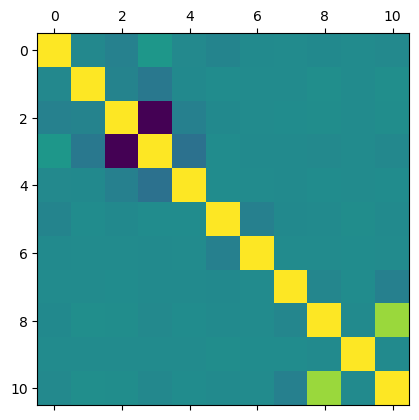

In [49]:
#Se podra predecir viajes atipicos
import matplotlib.pyplot as plt
plt.matshow(N_df.corr())
plt.show()

In [50]:
import pandas as pd
import numpy as np

corr = N_df.corr()
corr.style.background_gradient(cmap='coolwarm')

,Edad_Usuario,Genero_Usuario_?,Genero_Usuario_F,Genero_Usuario_M,Genero_Usuario_O,hora,minuto,dia_del_mes,dia_de_la_semana,mes,es_fin_de_semana
Edad_Usuario,1.000000,-0.025238,-0.078456,0.088330,-0.021846,-0.057334,-0.002911,0.002181,-0.012643,-0.000900,-0.019781
Genero_Usuario_?,-0.025238,1.000000,-0.065903,-0.159503,-0.014809,0.008750,0.000843,0.000711,0.021559,0.001226,0.026123
Genero_Usuario_F,-0.078456,-0.065903,1.000000,-0.929583,-0.086308,-0.013440,0.004024,0.005075,0.014209,-0.000679,0.019381
Genero_Usuario_M,0.088330,-0.159503,-0.929583,1.000000,-0.208889,0.007793,-0.004015,-0.004233,-0.020603,0.000075,-0.026811
Genero_Usuario_O,-0.021846,-0.014809,-0.086308,-0.208889,1.000000,0.010989,-0.000280,-0.002887,0.006445,0.001026,0.006952
hora,-0.057334,0.008750,-0.013440,0.007793,0.010989,1.000000,-0.087231,-0.013434,-0.008126,0.013433,-0.006664
minuto,-0.002911,0.000843,0.004024,-0.004015,-0.000280,-0.087231,1.000000,0.001608,0.004147,0.005917,0.002564
dia_del_mes,0.002181,0.000711,0.005075,-0.004233,-0.002887,-0.013434,0.001608,1.000000,-0.045772,0.011955,-0.089637
dia_de_la_semana,-0.012643,0.021559,0.014209,-0.020603,0.006445,-0.008126,0.004147,-0.045772,1.000000,-0.006812,0.711213
mes,-0.000900,0.001226,-0.000679,0.000075,0.001026,0.013433,0.005917,0.011955,-0.006812,1.000000,-0.003093


In [51]:
N_df_y = df[['duracion']]

In [52]:
N_df_y.head()

,duracion
0,0 days 00:03:01
1,0 days 00:09:01
2,0 days 00:12:23
3,0 days 00:06:57
4,0 days 00:25:49


In [53]:
# Convertir la duración a segundos totales
N_df_y = df['duracion'].dt.total_seconds()
# Ver resultado
print(N_df_y.head())

0     181.0
1     541.0
2     743.0
3     417.0
4    1549.0
Name: duracion, dtype: float64


In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

In [55]:
#No usar
X_train, X_val, y_train, y_val = train_test_split(
    N_df, N_df_y, test_size=0.1, random_state=42
)

In [56]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [57]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [58]:
X_test_scaled = scaler.transform(X_val)

In [59]:
y_pred = model.predict(X_test_scaled)

In [60]:
#Predecir duracion del viaje, predecir viajes atipicos
#CoD R^2; Real-world Utility
#r^2 dice que hay un porcentaje de variabilidad
#Mape real world utility


In [61]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.0007
